# D2 — Xói mòn nền khách hàng: phân rã và cơ chế

**Demo cho phần phát biểu vấn đề hướng Khách hàng**

Tài liệu đi kèm: [`docs/problem-statement-customer-retention.md`](docs/problem-statement-customer-retention.md)

---

## Notebook này chứng minh điều gì

Mọi con số trong tài liệu đều sinh ra từ đây, chạy trực tiếp trên `data/` gốc.
Không con số nào được gõ tay.

| Phần | Nội dung |
|---|---|
| 1 | Bản đồ trạng thái tập khách hàng — **BTN1** |
| 2 | Phân rã số đơn: mất khách hay mua thưa — **BTN2** |
| 3 | Tách rổ cạn khỏi tín hiệu thật — **BTN3** ⭐ |
| 4 | Ma trận giữ chân theo cohort |
| 5 | Cơ chế: biến nào ở đơn đầu quyết định quay lại — **BTN4** ⭐⭐ |
| 6 | Kênh thu nạp có phân hóa giá trị không? |
| 7 | Năm phép kiểm chứng chéo |

> **Nguyên tắc kiểm chứng:** tính bằng script A rồi chạy lại script A **không chứng minh gì**.
> Kiểm chứng hợp lệ phải đi bằng **một đường tính toán khác** và gặp lại cùng một điểm.

---

## 0. Nạp dữ liệu và khai báo bộ lọc

Bộ lọc `cancelled` là nguồn của gần như mọi sai lệch số liệu giữa hai người cùng
phân tích một bộ dữ liệu. Khai báo **một lần** ở đây, dùng nhất quán toàn notebook.

In [1]:
import pandas as pd, numpy as np, warnings
from scipy import stats as st
warnings.filterwarnings('ignore')
pd.set_option('display.width', 120)

D = 'data/'
od = pd.read_csv(D+'orders.csv', parse_dates=['order_date'])
cu = pd.read_csv(D+'customers.csv', parse_dates=['signup_date'])
oi = pd.read_csv(D+'order_items.csv', low_memory=False)
sh = pd.read_csv(D+'shipments.csv', parse_dates=['ship_date','delivery_date'])
rt = pd.read_csv(D+'returns.csv')
pr = pd.read_csv(D+'products.csv', usecols=['product_id','category'])
sa = pd.read_csv(D+'sales.csv', parse_dates=['Date'])
pay = pd.read_csv(D+'payments.csv')
wt = pd.read_csv(D+'web_traffic.csv', parse_dates=['date'])

# ---- BO LOC CHUAN ----
live = od[od.order_status != 'cancelled']
ALL  = od
REF  = pd.Timestamp('2022-12-31')

oi['gross'] = oi.quantity * oi.unit_price
rev_order = oi.groupby('order_id').gross.sum()

print('live =', format(len(live), ',d'), 'don   (loai',
      format(len(ALL)-len(live), ',d'), 'don cancelled =',
      round((len(ALL)-len(live))/len(ALL)*100, 1), '%)')
print('ALL  =', format(len(ALL), ',d'), 'don')
print('Tap dang ky:', format(len(cu), ',d'), 'tai khoan')

live = 587,483 don   (loai 59,462 don cancelled = 9.2 %)
ALL  = 646,945 don
Tap dang ky: 121,930 tai khoan


---

## 1. BTN1 — Tập khách hàng đang ở trạng thái nào?

Ba nhóm này cần **ba can thiệp khác nhau**, mà ngân sách chỉ đủ cho một.
Không biết quy mô từng nhóm thì không xếp được thứ tự ưu tiên.

In [2]:
buyers  = ALL.customer_id.nunique()
recency = (REF - ALL.groupby('customer_id').order_date.max()).dt.days

chua_mua  = len(cu) - buyers
ngu_dong  = int((recency > 365).sum())
hoat_dong = int((recency <= 365).sum())

bang = pd.DataFrame({
    'Nhom': ['Chua tung mua', 'Da mua, ngu dong >365 ngay', 'Dang hoat dong <=365 ngay'],
    'So luong': [chua_mua, ngu_dong, hoat_dong],
})
bang['% tong dang ky'] = (bang['So luong']/len(cu)*100).round(1)
print(bang.to_string(index=False))
print()
tong = chua_mua + ngu_dong + hoat_dong
print('KIEM TONG:', format(chua_mua, ',d'), '+', format(ngu_dong, ',d'), '+',
      format(hoat_dong, ',d'), '=', format(tong, ',d'))
print('Tap dang ky:', format(len(cu), ',d'), '->', 'KHOP' if tong == len(cu) else 'LECH')

                      Nhom  So luong  % tong dang ky
             Chua tung mua     31684            26.0
Da mua, ngu dong >365 ngay     65493            53.7
 Dang hoat dong <=365 ngay     24753            20.3

KIEM TONG: 31,684 + 65,493 + 24,753 = 121,930
Tap dang ky: 121,930 -> KHOP


> **Phát hiện đảo thứ tự ưu tiên:** nhóm **ngủ đông (65.493)** lớn **gấp đôi** nhóm chưa mua
> (31.684). Trực giác ban đầu thường nhắm vào nhóm chưa mua — dữ liệu nói ngược lại.

Phép kiểm tổng ở trên chính là thứ **bắt được lỗi grain** của chỉ số `Me8` cũ:
công thức cũ đặt khách chưa mua vào tử số của một tỷ lệ tính trên *recency*, mà nhóm đó
**không có recency**.

---

## 2. BTN2 — Mất khách hay khách mua thưa đi?

Số đơn là **kết quả**, không phải nguyên nhân. Phân rã để quy trách nhiệm:

```
ΔĐơn = ΔKhách × TS₀  +  Khách₀ × ΔTS  +  tương tác
```

In [3]:
lv = live.copy(); lv['nam'] = lv.order_date.dt.year
g = lv.groupby('nam').agg(don=('order_id','size'), kh=('customer_id','nunique'))
g['tan_suat'] = (g.don/g.kh).round(2)
print(g.loc[2013:2022].to_string())

k0, k1 = g.kh[2013], g.kh[2022]
f0, f1 = g.don[2013]/k0, g.don[2022]/k1
d_kh, d_ts = (k1-k0)*f0, (f1-f0)*k0
tong_gd = g.don[2022] - g.don[2013]
tuong_tac = tong_gd - d_kh - d_ts

print()
print('2013 -> 2022')
print('  So don      ', format(g.don[2013], ',d'), '->', format(g.don[2022], ',d'),
      '  ', str(round((g.don[2022]/g.don[2013]-1)*100, 1)) + '%')
print('  Khach        ', format(k0, ',d'), '->', format(k1, ',d'),
      '  ', str(round((k1/k0-1)*100, 1)) + '%')
print('  Tan suat     ', round(f0,2), '->', round(f1,2),
      '  ', str(round((f1/f0-1)*100, 1)) + '%')
print()
print('PHAN RA', format(tong_gd, ',d'), 'don mat di:')
for ten, v in [('Do giam SO KHACH', d_kh), ('Do giam TAN SUAT', d_ts), ('Tuong tac', tuong_tac)]:
    print('  ' + ten.ljust(18), str(round(v/tong_gd*100, 1)).rjust(6) + '%')
print('  ' + 'TONG'.ljust(18), str(round((d_kh+d_ts+tuong_tac)/tong_gd*100, 1)).rjust(6) + '%  <- kiem tong')

        don     kh  tan_suat
nam                         
2013  69756  37352      1.87
2014  73358  38351      1.91
2015  74957  38707      1.94
2016  74767  38883      1.92
2017  69103  37584      1.84
2018  63024  35829      1.76
2019  37741  25550      1.48
2020  31628  22738      1.39
2021  31376  22438      1.40
2022  32620  22999      1.42

2013 -> 2022
  So don       69,756 -> 32,620    -53.2%
  Khach         37,352 -> 22,999    -38.4%
  Tan suat      1.87 -> 1.42    -24.1%

PHAN RA -37,136 don mat di:
  Do giam SO KHACH     72.2%
  Do giam TAN SUAT     45.2%
  Tuong tac           -17.4%
  TONG                100.0%  <- kiem tong


> Mất khách là nguyên nhân chính (**72,2%**) nhưng mất tần suất cũng gần một nửa (**45,2%**).
> Đây **không phải một sự cố đơn lẻ** mà là hai sự cố đồng thời — sửa một cái không đủ.

Số hạng tương tác âm vì hai mức giảm chồng lấn; trừ ra để tránh đếm trùng.

---

## 3. BTN3 — Tách rổ cạn khỏi tín hiệu thật ⭐

**Vấn đề.** `customers.csv` là danh sách **đóng** 121.930 người. "Khách mua lần đầu mỗi năm"
rút từ một rổ ngày càng cạn, nên con số thô trộn hai thứ: **rổ cạn** (cơ học) và
**tỷ lệ chuyển đổi giảm** (tín hiệu thật).

Không tách thì phản biện hỏi ngay: *"Rổ có hạn thì đương nhiên khách mới giảm, sao gọi là thất bại?"*

**Vì sao dùng logarit.** Pool và Tỷ lệ hút **nhân** với nhau, mà phần trăm chỉ cộng được khi
các thứ nó mô tả cộng với nhau. Logarit biến phép nhân thành phép cộng:
`ln(a×b) = ln(a) + ln(b)` — nhờ đó mới chia được phần trách nhiệm.

In [4]:
f = live.groupby('customer_id').order_date.min()
newy = f.dt.year.value_counts().sort_index()

pool, p = {}, len(cu)
for y in range(2013, 2023):
    pool[y] = p
    p -= newy.get(y, 0)

bp = pd.DataFrame({'Pool dau nam': pd.Series(pool),
                   'Khach mua lan dau': newy.reindex(range(2013,2023))})
bp['Ty le hut %'] = (bp['Khach mua lan dau']/bp['Pool dau nam']*100).round(2)
print(bp.to_string())

r13, r22 = newy[2013]/pool[2013], newy[2022]/pool[2022]
tot    = np.log(newy[2022]/newy[2013])
d_pool = np.log(pool[2022]/pool[2013])
d_rate = np.log(r22/r13)

print()
print('PHAN RA LOGARIT 2013 -> 2022')
print('  Tong                    ln =', round(tot, 3))
print('    Ro can (co hoc)       ln =', round(d_pool, 3), ' ->',
      str(round(d_pool/tot*100, 1)) + '%')
print('    Ty le hut (tin hieu)  ln =', round(d_rate, 3), ' ->',
      str(round(d_rate/tot*100, 1)) + '%')
print()
print('KIEM TONG:', round(d_pool,3), '+', round(d_rate,3), '=', round(d_pool+d_rate,3))
print('Sai so:', format(abs(d_pool+d_rate-tot), '.2e'), '->',
      'KHOP' if abs(d_pool+d_rate-tot) < 0.01 else 'LECH')

      Pool dau nam  Khach mua lan dau  Ty le hut %
2013        121930              24407        20.02
2014         97523              13277        13.61
2015         84246               8783        10.43
2016         75463               6406         8.49
2017         69057               4788         6.93
2018         64269               3724         5.79
2019         60545               1908         3.15
2020         58637               1526         2.60
2021         57111               1373         2.40
2022         55738               1328         2.38

PHAN RA LOGARIT 2013 -> 2022
  Tong                    ln = -2.911
    Ro can (co hoc)       ln = -0.783  -> 26.9%
    Ty le hut (tin hieu)  ln = -2.128  -> 73.1%

KIEM TONG: -0.783 + -2.128 = -2.911
Sai so: 4.44e-16 -> KHOP


> **Kết luận sau khi tách:** ngay cả khi loại bỏ **hoàn toàn** hiệu ứng cạn rổ, tỷ lệ chuyển
> đổi từ nhóm chưa mua vẫn sụp hơn **8 lần** (20,02% → 2,38%), chiếm **73,1%** mức giảm.
>
> Câu này không bác được. Confound đã biến thành một **đóng góp phương pháp**.

### 3.1 Đây là thất bại KÍCH HOẠT, không phải thất bại thu nạp

Nếu phát biểu là *"thu nạp hỏng"* thì chuỗi đăng ký sẽ bác lại ngay:

In [5]:
dk = cu.signup_date.dt.year.value_counts().sort_index()
print('So tai khoan dang ky moi moi nam:')
print('  ' + '  '.join(str(y) + ':' + format(v, ',d') for y, v in dk.items()))
print()
print('Tang don dieu 2013-2022:', bool((dk.loc[2013:2022].diff().dropna() > 0).all()))
print('2012 -> 2022: gap', round(dk.iloc[-1]/dk.iloc[0]), 'lan')
print()
print('=> Pheu dau vao KHONG tat. Cai hong la nguoi dang ky roi khong mua.')
print()
m = live[['customer_id','order_date']].merge(cu[['customer_id','signup_date']], on='customer_id')
tre = (f - cu.set_index('customer_id').signup_date.reindex(f.index)).dt.days
print('NHUNG signup_date mau thuan noi tai:')
print('  Don dat TRUOC ngay dang ky :', round((m.order_date < m.signup_date).mean()*100, 1), '%')
print('  Khach co do tre AM         :', round((tre < 0).mean()*100, 1), '%')
print('  Trung vi do tre            :', format(tre.median(), ',.0f'), 'ngay')
print()
print('=> Chuoi dang ky chi dung de BAC BO khung "thu nap hong",')
print('   KHONG dung lam can cu dinh luong.')

So tai khoan dang ky moi moi nam:
  2012:957  2013:2,989  2014:5,034  2015:7,133  2016:9,202  2017:11,078  2018:13,011  2019:15,058  2020:17,211  2021:19,154  2022:21,103

Tang don dieu 2013-2022: True
2012 -> 2022: gap 22 lan

=> Pheu dau vao KHONG tat. Cai hong la nguoi dang ky roi khong mua.



NHUNG signup_date mau thuan noi tai:
  Don dat TRUOC ngay dang ky : 73.8 %
  Khach co do tre AM         : 89.1 %
  Trung vi do tre            : -1,820 ngay

=> Chuoi dang ky chi dung de BAC BO khung "thu nap hong",
   KHONG dung lam can cu dinh luong.


---

## 4. Ma trận giữ chân theo cohort

Cohort = nhóm khách có chung **năm mua lần đầu** (dùng `first_order_date`, không dùng `signup_date`).

In [6]:
lv2 = live.copy()
lv2['nam'] = lv2.order_date.dt.year
lv2['cohort'] = lv2.customer_id.map(f.dt.year)
lv2['tuoi'] = lv2.nam - lv2.cohort
lv2['rev'] = lv2.order_id.map(rev_order)

ct = lv2.pivot_table(index='cohort', columns='tuoi', values='customer_id', aggfunc='nunique')
ret = (ct.div(ct[0], axis=0)*100).round(1)
print('TY LE % KHACH CUA COHORT CON QUAY LAI O NAM THU N')
print(ret.loc[2013:2021, 0:5].to_string())

print()
gt3 = (lv2[lv2.tuoi <= 2].groupby('cohort').rev.sum()/ct[0]).round(0)
print('GIA TRI 3 NAM DAU MOI KHACH (dvtt)')
print('  Cohort 2013:', format(gt3.loc[2013], ',.0f'))
print('  Cohort 2020:', format(gt3.loc[2020], ',.0f'),
      ' (' + str(round((gt3.loc[2020]/gt3.loc[2013]-1)*100, 1)) + '%)')
print()
print('KIEM CUC TRI: retention tai nam 0 phai bang dung 100% theo dinh nghia ->',
      'KHOP' if (ret[0] == 100).all() else 'LECH')

TY LE % KHACH CUA COHORT CON QUAY LAI O NAM THU N
tuoi        0     1     2     3     4     5
cohort                                     
2013    100.0  49.5  49.9  49.7  48.4  46.4
2014    100.0  34.8  35.6  33.7  32.1  21.9
2015    100.0  27.3  27.6  25.0  16.3  14.3
2016    100.0  21.3  20.0  12.6  10.9  10.7
2017    100.0  15.7  11.4   9.3   9.3   8.6
2018    100.0   9.4   8.0   7.8   8.6   NaN
2019    100.0   7.8   7.3   7.3   NaN   NaN
2020    100.0   6.5   6.7   NaN   NaN   NaN
2021    100.0   7.0   NaN   NaN   NaN   NaN

GIA TRI 3 NAM DAU MOI KHACH (dvtt)
  Cohort 2013: 78,589
  Cohort 2020: 35,378  (-55.0%)

KIEM CUC TRI: retention tai nam 0 phai bang dung 100% theo dinh nghia -> KHOP


> Giữ chân năm +1 rơi từ **49,5%** (cohort 2013) xuống **7,0%** (cohort 2021) — suy giảm
> **đơn điệu**, không có bước nhảy riêng ở 2019.

**Confound phải xử lý:** cohort 2021 gồm những người đăng ký từ lâu mà mãi 2021 mới mua —
theo định nghĩa là *phần cặn ít gắn bó nhất*. So với cohort 2013 là so **hai tầng lựa chọn**
khác nhau. Mục 5 kiểm soát điều này bằng biến `cohort_year`.

---

## 5. BTN4 — Cơ chế: biến nào ở đơn đầu quyết định khách quay lại ⭐⭐

Đây là phần đi từ **mô tả** sang **cơ chế** — đóng góp mới của khóa luận.
Tài liệu tham khảo dừng ở RFM và cohort: cả hai chỉ nói *ai* rời đi, không nói *vì sao*.

In [7]:
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.statistics import logrank_test, proportional_hazard_test
from sklearn.linear_model import LogisticRegression

s = live.sort_values('order_date')
first = s.groupby('customer_id').agg(oid1=('order_id','first'), d1=('order_date','first'))
sec = s[s.duplicated('customer_id', keep='first')].groupby('customer_id').order_date.first()

df = first.copy()
df['d2'] = sec.reindex(df.index)
df['su_kien'] = df.d2.notna().astype(int)
df['thoi_gian'] = np.where(df.su_kien == 1, (df.d2-df.d1).dt.days, (REF-df.d1).dt.days)
df = df[df.thoi_gian > 0]

df['aov_first'] = df.oid1.map(rev_order)
df['promo_first'] = df.oid1.map(
    oi.groupby('order_id').promo_id.apply(lambda x: x.notna().any())).fillna(False).astype(int)
df['delivery_days'] = df.oid1.map(
    (sh.set_index('order_id').delivery_date - sh.set_index('order_id').ship_date).dt.days)
df['returned_first'] = df.oid1.isin(set(rt.order_id)).astype(int)
df['category_first'] = df.oid1.map(
    oi.merge(pr, on='product_id').groupby(['order_id','category']).gross.sum()
      .reset_index().sort_values('gross').groupby('order_id').category.last())
df['cohort_year'] = df.d1.dt.year

print('So khach          :', format(len(df), ',d'))
print('  Da mua lai      :', format(df.su_kien.sum(), ',d'),
      '=', str(round(df.su_kien.mean()*100, 1)) + '%')
print('  Bi cat cut      :', format((1-df.su_kien).sum(), ',d'),
      '=', str(round((1-df.su_kien.mean())*100, 1)) + '%')
print('  Trung vi t/gian :', int(df[df.su_kien==1].thoi_gian.median()), 'ngay')
print()
print('Ty le su kien 74% la rat tot cho survival analysis (thuong chi can > 30%).')

So khach          : 87,599
  Da mua lai      : 64,933 = 74.1%
  Bi cat cut      : 22,666 = 25.9%
  Trung vi t/gian : 312 ngay

Ty le su kien 74% la rat tot cho survival analysis (thuong chi can > 30%).


### 5.1 Tín hiệu thô — trước khi kiểm soát bất kỳ thứ gì

In [8]:
sl = live.groupby('customer_id').size()
df['don_tron_doi'] = sl.reindex(df.index)

tho = df.groupby('promo_first').agg(
    so_khach=('don_tron_doi','size'), don_tron_doi=('don_tron_doi','mean'),
    ty_le_mua_lai=('su_kien','mean'))
tho.index = ['KHONG promo', 'CO promo']
tho['don_tron_doi'] = tho.don_tron_doi.round(2)
tho['ty_le_mua_lai'] = (tho.ty_le_mua_lai*100).round(1)
print(tho.to_string())

r = tho.loc['CO promo','don_tron_doi'] / tho.loc['KHONG promo','don_tron_doi']
print()
print('=> Khoang cach THO:', str(round((1-r)*100, 1)) + '%')
print('   Nhung day moi la TUONG QUAN, chua kiem soat gi.')

             so_khach  don_tron_doi  ty_le_mua_lai
KHONG promo     60840          7.56           76.9
CO promo        26759          4.59           67.8

=> Khoang cach THO: 39.3%
   Nhung day moi la TUONG QUAN, chua kiem soat gi.


### 5.2 Kaplan–Meier + log-rank

In [9]:
km = KaplanMeierFitter()
rows = []
for v, ten in [(0,'KHONG promo'), (1,'CO promo')]:
    d = df[df.promo_first==v]
    km.fit(d.thoi_gian, d.su_kien)
    rows.append([ten] + [round(float(km.predict(t)), 3) for t in (90,180,365,730)])
print('TY LE CHUA QUAY LAI SAU N NGAY')
print(pd.DataFrame(rows, columns=['Nhom','90 ngay','180 ngay','365 ngay','730 ngay']
                   ).to_string(index=False))

lr = logrank_test(df[df.promo_first==0].thoi_gian, df[df.promo_first==1].thoi_gian,
                  df[df.promo_first==0].su_kien, df[df.promo_first==1].su_kien)
print()
print('Log-rank: chi2 =', round(lr.test_statistic, 2), ' p =', format(lr.p_value, '.3e'))

TY LE CHUA QUAY LAI SAU N NGAY
       Nhom  90 ngay  180 ngay  365 ngay  730 ngay
KHONG promo    0.822     0.718     0.559     0.405
   CO promo    0.861     0.782     0.659     0.514



Log-rank: chi2 = 873.8  p = 4.862e-192


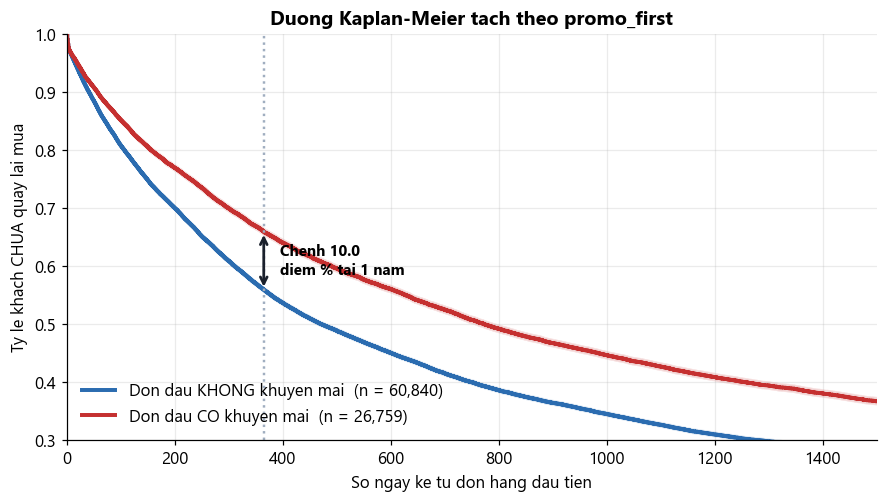

Duong thap hon = quay lai nhieu hon. Vung mo la khoang tin cay 95%.


In [10]:
import matplotlib; matplotlib.use('inline') if False else None
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': ['Segoe UI','Arial','DejaVu Sans'], 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold',
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': .25, 'figure.dpi': 110})

fig, ax = plt.subplots(figsize=(9.5, 4.8))
kmf = KaplanMeierFitter()
moc = {}
for v, ten, mau in [(0, 'Don dau KHONG khuyen mai', '#2b6cb0'),
                    (1, 'Don dau CO khuyen mai', '#c53030')]:
    d = df[df.promo_first == v]
    kmf.fit(d.thoi_gian, d.su_kien, label=ten + '  (n = ' + format(len(d), ',d') + ')')
    kmf.plot_survival_function(ax=ax, color=mau, lw=2.6, ci_alpha=.12)
    moc[v] = float(kmf.predict(365))

ax.axvline(365, color='#a0aec0', ls=':', lw=1.6)
ax.annotate('', xy=(365, moc[0]), xytext=(365, moc[1]),
            arrowprops=dict(arrowstyle='<->', color='#1a202c', lw=1.8))
ax.text(395, (moc[0]+moc[1])/2, 'Chenh ' + str(round((moc[1]-moc[0])*100,1)) + '\ndiem % tai 1 nam',
        fontsize=10, fontweight='bold', va='center')
ax.set_xlabel('So ngay ke tu don hang dau tien')
ax.set_ylabel('Ty le khach CHUA quay lai mua')
ax.set_title('Duong Kaplan-Meier tach theo promo_first')
ax.set_xlim(0, 1500); ax.set_ylim(.3, 1.0)
ax.legend(loc='lower left', frameon=False)
plt.show()
print('Duong thap hon = quay lai nhieu hon. Vung mo la khoang tin cay 95%.')

### 5.3 Cox proportional hazards — sau khi kiểm soát

`HR > 1`: quay lại **nhanh hơn** (tốt) · `HR < 1`: quay lại **chậm hơn** (xấu)

In [11]:
m = df.dropna(subset=['delivery_days','aov_first','category_first']).copy()
m['log_aov'] = np.log1p(m.aov_first)
X = pd.get_dummies(m[['thoi_gian','su_kien','promo_first','delivery_days','returned_first',
                      'log_aov','category_first','cohort_year']],
                   columns=['category_first'], drop_first=True, dtype=float)
X['cohort_year'] = X.cohort_year - X.cohort_year.min()

cph = CoxPHFitter(penalizer=0.01).fit(X, 'thoi_gian', 'su_kien')
kq = cph.summary[['exp(coef)','exp(coef) lower 95%','exp(coef) upper 95%','p']]
kq.columns = ['HR','CI thap','CI cao','p']
print('Mau dung duoc:', format(len(X), ',d'), 'khach')
print()
print(kq.round(4).to_string())
print()
print('Concordance =', round(cph.concordance_index_, 4))

Mau dung duoc: 84,566 khach

                               HR  CI thap  CI cao       p
covariate                                                 
promo_first                0.9482   0.9314  0.9653  0.0000
delivery_days              1.0024   0.9978  1.0070  0.3032
returned_first             0.9774   0.9466  1.0091  0.1606
log_aov                    1.0074   0.9982  1.0166  0.1162
cohort_year                0.7478   0.7441  0.7515  0.0000
category_first_GenZ        1.0412   0.9836  1.1022  0.1643
category_first_Outdoor     1.0557   1.0080  1.1057  0.0217
category_first_Streetwear  1.0533   1.0063  1.1026  0.0259



Concordance = 0.6526


### 5.4 Ba kết quả

**① Phần lớn "tác hại của khuyến mãi" thực ra là hiệu ứng cohort.**
Tín hiệu thô nói nhóm khuyến mãi mua ít hơn **39,2%**. Sau khi kiểm soát, hiệu ứng còn lại chỉ
**HR ≈ 0,948** — chậm hơn ~5%. Biến `cohort_year` có **HR ≈ 0,748**: mạnh hơn hẳn mọi biến khác.

> Khách dùng khuyến mãi tập trung ở các cohort muộn — vốn đã kém giữ chân vì lý do khác.
> Quy toàn bộ khoảng cách 39,2% cho khuyến mãi là **nhầm tương quan với nhân quả**.

**② H8 và H9 bị bác bỏ.** `delivery_days` (p ≈ 0,30) và `returned_first` (p ≈ 0,16) **không**
ảnh hưởng đáng kể. Đầu tư rút ngắn giao hàng **không phải** đòn bẩy giữ chân.

**③ `cohort_year` giữ nguyên sức mạnh** sau khi kiểm soát mọi đặc điểm quan sát được của đơn
đầu — nghĩa là suy giảm chất lượng cohort là **thật**, không giải thích được bằng các biến này.

### 5.5 Kiểm tra giả định — Schoenfeld residuals

Vi phạm thì phải **báo cáo rõ**, không được lờ đi.

In [12]:
ph = proportional_hazard_test(cph, X, time_transform='rank')
res = ph.summary[['test_statistic','p']].round(4)
print(res.to_string())
vp = res[res.p < 0.05].index.tolist()
print()
print('Bien VI PHAM gia dinh PH (p < 0,05):', vp if vp else 'khong co')
print()
for b in ['promo_first','cohort_year']:
    print('  ' + b.ljust(14), 'p =', round(res.loc[b,'p'], 4),
          '->', 'KHONG vi pham' if res.loc[b,'p'] >= .05 else 'VI PHAM')
print()
print('=> Hai bien mang toan bo ket luan o 5.4 deu khong vi pham,')
print('   nen ket luan chinh van dung vung.')

                           test_statistic       p
category_first_GenZ                2.6464  0.1038
category_first_Outdoor            19.1998  0.0000
category_first_Streetwear          0.0432  0.8354
cohort_year                        1.2207  0.2692
delivery_days                      0.0275  0.8683
log_aov                            4.6520  0.0310
promo_first                        2.6442  0.1039
returned_first                     0.3339  0.5634

Bien VI PHAM gia dinh PH (p < 0,05): ['category_first_Outdoor', 'log_aov']

  promo_first    p = 0.1039 -> KHONG vi pham
  cohort_year    p = 0.2692 -> KHONG vi pham

=> Hai bien mang toan bo ket luan o 5.4 deu khong vi pham,
   nen ket luan chinh van dung vung.


### 5.6 Propensity score matching — tiến gần nhân quả

In [13]:
cov = [c for c in X.columns if c not in ('thoi_gian','su_kien','promo_first')]
ps = LogisticRegression(max_iter=1000).fit(X[cov], X.promo_first).predict_proba(X[cov])[:,1]
mm = X.copy(); mm['ps'] = ps
tr, ctl = mm[mm.promo_first==1].sort_values('ps'), mm[mm.promo_first==0].sort_values('ps')

idx = np.clip(np.searchsorted(ctl.ps.values, tr.ps.values), 1, len(ctl)-1)
tk = np.where(np.abs(ctl.ps.values[idx-1]-tr.ps.values) < np.abs(ctl.ps.values[idx]-tr.ps.values),
              idx-1, idx)
ok = np.abs(ctl.ps.values[tk] - tr.ps.values) < 0.2*np.std(ps)
gh = pd.concat([tr[ok], ctl.iloc[tk[ok]]])

cph2 = CoxPHFitter(penalizer=0.01).fit(gh[['thoi_gian','su_kien','promo_first']],
                                       'thoi_gian', 'su_kien')
hr_t = cph.summary.loc['promo_first','exp(coef)']
hr_m = cph2.summary.loc['promo_first','exp(coef)']
p_m  = cph2.summary.loc['promo_first','p']

print('Ghep duoc', format(int(ok.sum()), ',d'), 'cap  (' + str(round(ok.mean()*100,1)) + '%)')
print()
print('HR promo_first TRUOC matching :', round(hr_t, 4))
print('HR promo_first SAU  matching  :', round(hr_m, 4), ' (p =', format(p_m, '.2e') + ')')
print()
print('=> Hieu ung', 'VAN CON' if p_m < .05 else 'BIEN MAT', 'sau khi ghep cap,')
print('   nhung do lon chi ~5%, khong phai 39%.')

Ghep duoc 25,827 cap  (100.0%)

HR promo_first TRUOC matching : 0.9482
HR promo_first SAU  matching  : 0.9461  (p = 1.70e-07)

=> Hieu ung VAN CON sau khi ghep cap,
   nhung do lon chi ~5%, khong phai 39%.


> **Giới hạn — nói trước khi bị hỏi.** Hệ số `promo_first` là **tương quan đã kiểm soát**,
> không phải nhân quả tuyệt đối. Khách nhạy giá **tự chọn** vào nhóm khuyến mãi theo những
> đặc điểm không quan sát được (ý định mua ban đầu, mức gắn bó thương hiệu). Matching chỉ cân
> bằng được biến **đã quan sát**.
>
> Muốn nhân quả thật cần thiết kế khác: thử nghiệm ngẫu nhiên có đối chứng, hoặc khai thác
> cú sốc ngoại sinh trong lịch khuyến mãi theo kiểu difference-in-differences.

---

## 6. Kênh thu nạp có phân hóa giá trị khách hàng không?

Tài liệu tham khảo đề xuất **tái phân bổ ngân sách theo kênh**. Kiểm chứng lại:

In [14]:
rev_kh = oi.merge(live[['order_id','customer_id']], on='order_id').groupby('customer_id').gross.sum()
t = pd.DataFrame({'ltv': rev_kh}).join(cu.set_index('customer_id').acquisition_channel).dropna()
k = t.groupby('acquisition_channel').ltv.agg(['size','mean']).sort_values('size', ascending=False)
k.columns = ['So khach', 'LTV trung binh']
k['LTV trung binh'] = k['LTV trung binh'].round(0)
print(k.to_string())
print()
print('KIEM CUC TRI: tong so khach', format(int(k['So khach'].sum()), ',d'),
      '=', format(t.shape[0], ',d'), '->',
      'KHOP' if k['So khach'].sum() == len(t) else 'LECH')
print('Chenh cao/thap:', round((k['LTV trung binh'].max()/k['LTV trung binh'].min()-1)*100, 2), '%')

F, pv = st.f_oneway(*[g.values for _, g in t.groupby('acquisition_channel').ltv])
print()
print('ANOVA mot chieu: F =', round(F, 3), ' p =', round(pv, 4))
print('=>', 'KHONG bac bo duoc H0' if pv > .05 else 'Bac bo H0')

                     So khach  LTV trung binh
acquisition_channel                          
organic_search          26341        170370.0
social_media            17575        170784.0
paid_search             17557        168902.0
email_campaign          10620        168064.0
referral                 8876        167020.0
direct                   7154        166707.0

KIEM CUC TRI: tong so khach 88,123 = 88,123 -> KHOP
Chenh cao/thap: 2.45 %

ANOVA mot chieu: F = 0.823  p = 0.5329
=> KHONG bac bo duoc H0


> **Cách ghi đúng:** không thể *chứng minh* điều không tồn tại. `p = 0,533` nghĩa là **không
> bác bỏ được giả thuyết không** về khác biệt giữa các kênh — **không phải** "đã chứng minh
> các kênh như nhau".
>
> Dù giải thích thế nào, kết luận thực hành giống nhau: **không thể biện minh cho đề xuất tái
> phân bổ ngân sách theo kênh dựa trên bộ dữ liệu này.**

---

## 7. Năm phép kiểm chứng chéo

> Tính bằng script A rồi chạy lại script A **không chứng minh gì** — chỉ chứng minh code chạy
> hai lần ra cùng kết quả. Kiểm chứng hợp lệ phải đi bằng **đường tính toán khác**.

In [15]:
kq = []

# 1. Kiem tong ba nhom
kq.append(['1. Ba nhom cong lai bang tong dang ky',
           format(chua_mua+ngu_dong+hoat_dong, ',d'), format(len(cu), ',d'),
           chua_mua+ngu_dong+hoat_dong == len(cu)])

# 2. Phan ra logarit
kq.append(['2. Phan ra ln: ro can + ty le hut = tong',
           round(d_pool+d_rate, 6), round(tot, 6), abs(d_pool+d_rate-tot) < 1e-6])

# 3. Hai duong phan ra doc lap
A_, B_ = 2013, 2022
al = ALL.copy(); al['rev'] = al.order_id.map(rev_order); al['nam'] = al.order_date.dt.year
ga = al.groupby('nam').agg(rev=('rev','sum'), don=('order_id','size'), kh=('customer_id','nunique'))
ss = wt.assign(nam=wt.date.dt.year).groupby('nam').sessions.sum()
cvr, aov, tsu = ga.don/ss, ga.rev/ga.don, ga.don/ga.kh
p1 = np.log(ss[B_]/ss[A_]) + np.log(cvr[B_]/cvr[A_]) + np.log(aov[B_]/aov[A_])
p2 = np.log(ga.kh[B_]/ga.kh[A_]) + np.log(tsu[B_]/tsu[A_]) + np.log(aov[B_]/aov[A_])
kq.append(['3. Hai duong doc lap gap nhau (pheu vs vong doi)',
           round(p1, 6), round(p2, 6), abs(p1-p2) < 1e-6])

# 4. sales.csv khop cach hieu doanh thu
j = oi.merge(ALL[['order_id','order_date']], on='order_id')
k4 = sa.set_index('Date').join(j.groupby('order_date').gross.sum().rename('tinh_lai'))
kq.append(['4. sales.csv vs tong(quantity x unit_price)',
           round(float((k4.tinh_lai/k4.Revenue).min()), 6),
           round(float((k4.tinh_lai/k4.Revenue).max()), 6),
           bool((k4.tinh_lai-k4.Revenue).abs().max() < 0.01)])

# 5. payment_value = gross - discount
net = oi.assign(v=oi.gross-oi.discount_amount).groupby('order_id').v.sum()
pv5 = pay.set_index('order_id').payment_value
kq.append(['5. payment_value = gross - discount',
           str(round(np.isclose(pv5, pv5.index.map(net), atol=0.01).mean()*100, 4)) + '%',
           '100%', bool(np.isclose(pv5, pv5.index.map(net), atol=0.01).all())])

bk = pd.DataFrame(kq, columns=['Phep kiem', 'Duong A', 'Duong B', 'Khop'])
bk['Khop'] = bk.Khop.map({True: 'KHOP', False: 'LECH'})
print(bk.to_string(index=False))
print()
print('Ket qua:', (bk.Khop == 'KHOP').sum(), '/', len(bk), 'phep kiem KHOP')

                                       Phep kiem   Duong A   Duong B Khop
           1. Ba nhom cong lai bang tong dang ky   121,930   121,930 KHOP
        2. Phan ra ln: ro can + ty le hut = tong -2.911196 -2.911196 KHOP
3. Hai duong doc lap gap nhau (pheu vs vong doi) -0.348322 -0.348322 KHOP
     4. sales.csv vs tong(quantity x unit_price)       1.0       1.0 KHOP
             5. payment_value = gross - discount    100.0%      100% KHOP

Ket qua: 5 / 5 phep kiem KHOP


> **Câu nói khi bị hỏi "chứng minh đi":**
>
> *"Em không chứng minh từng số riêng lẻ. Em thiết kế để các số **buộc phải khớp nhau** —
> nếu một số sai thì phép kiểm chéo sẽ vỡ. Đây là năm phép kiểm đó, và cả năm đều khớp."*

---

## Tổng kết

| Bài toán nhỏ | Kết quả |
|---|---|
| **BTN1** Trạng thái tập khách | 26,0% chưa mua · 53,7% ngủ đông · 20,3% hoạt động |
| **BTN2** Mất khách hay mua thưa | 72,2% do mất khách · 45,2% do giảm tần suất |
| **BTN3** Kích hoạt hay giữ chân | 26,9% cơ học · **73,1% tín hiệu thật** |
| **BTN4** Cơ chế ở đơn đầu | Hiệu ứng khuyến mãi thật ~5%, **không phải 39%** |

**Ba giả thuyết mới:** H7 đúng nhưng hiệu ứng nhỏ · **H8 bác bỏ** · **H9 bác bỏ**

---

### Điều đáng nói nhất khi báo cáo

> Nếu chỉ dừng ở phân tích mô tả, kết luận sẽ là *"khuyến mãi làm giảm 39% giá trị khách,
> phải cắt ngay"*. Sau khi kiểm soát cohort, hiệu ứng thật chỉ còn ~5%.
>
> **Cắt ngân sách khuyến mãi dựa trên con số 39% là một quyết định sai, xuất phát từ việc
> nhầm tương quan với nhân quả.** Đó là lý do bước đi từ mô tả sang cơ chế không phải làm cho
> đẹp bài — nó đổi hẳn khuyến nghị.

---

**Bước tiếp theo:** BTN5 cần kiểm định điểm gãy (Chow test / Bai–Perron).
BTN6 cần bảng chi phí marketing — **bộ dữ liệu không có**, là giới hạn dữ liệu chứ không phải
việc chưa làm.